In [12]:
import cleanup
import plotting
import statistics
%load_ext autoreload
%autoreload 2

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sbs
import math as math
import os
from os import listdir
import tkinter
from tkinter import filedialog
import scipy as scp
import scipy.stats as scpst

pd.options.mode.use_inf_as_na = True

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
tkinter.Tk().withdraw()
filepath = filedialog.askdirectory()
primary_df = cleanup.data_to_dataframe(filepath)

In [3]:
primary_df = primary_df[primary_df['Frame']<600]
primary_df = cleanup.calculate_distance_from_fixed_point(primary_df)
primary_df = cleanup.categorize_values(primary_df, 'X', 14, 1.5)

primary_df_interp = cleanup.interpolate_missing_values(primary_df)
primary_df_interp = cleanup.calculate_distance_from_fixed_point(primary_df_interp)

In [ ]:
# df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') |
#                               (primary_df_interp['Genotype'] == 'Trh')]
# df_WT_Trh_EA = df_WT_Trh[df_WT_Trh['Odour'] == 'EA']
# df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
# df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1P']

# df_Kir_CSD_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKir') 
#                                  | (primary_df_interp['Genotype'] == 'TrhxKir')
#                                  | (primary_df_interp['Genotype'] == 'CSDxKir')
#                                  | (primary_df_interp['Genotype'] == 'WTxCSD')
#                                  | (primary_df_interp['Genotype'] == 'WTxTrh')]
# df_Kir_CSD_Trh = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Starvation'] == 'Fed')
#                               | (df_Kir_CSD_Trh['Starvation'] == '5h')]
# df_Kir_CSD_Trh_EA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'EA']
# df_Kir_CSD_Trh_PA = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == 'PA']
# df_Kir_CSD_Trh_1P = df_Kir_CSD_Trh[df_Kir_CSD_Trh['Odour'] == '1P']

# df_Kir_CSD = df_Kir_CSD_Trh[(df_Kir_CSD_Trh['Genotype'] == 'WTxCSD')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'WTxKir')
#                         | (df_Kir_CSD_Trh['Genotype'] == 'CSDxKir')]
# df_Kir_CSD_EA = df_Kir_CSD[df_Kir_CSD['Odour'] == 'EA']

# df_TNT_uPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixUPN')]

# df_TNT_MPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
#                             |  (primary_df_interp['Genotype'] == 'TNTixMPN')]

# df_TNT_5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
#                             |    (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

# df_TNT_5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
#                             |   (primary_df_interp['Genotype'] == 'TNTix5HT7')]

In [4]:
# WT and Trh dataframes for PA and 1P 
df_WT_Trh = primary_df_interp[(primary_df_interp['Genotype'] == 'WT') 
                            | (primary_df_interp['Genotype'] == 'TRH')]


df_WT_Trh_PA = df_WT_Trh[df_WT_Trh['Odour'] == 'PA']
df_WT_Trh_1P = df_WT_Trh[df_WT_Trh['Odour'] == '1-P']


df_WT_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'WT')]
df_Trh_PA = df_WT_Trh_PA[(df_WT_Trh_PA['Genotype'] == 'TRH')]

df_WT_PA_104 = df_WT_PA[df_WT_PA['Concentration'] == '10-4']
df_Trh_PA_104 = df_Trh_PA[df_Trh_PA['Concentration'] == '10-4']



df_WT_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'WT')]
df_Trh_1P = df_WT_Trh_1P[(df_WT_Trh_1P['Genotype'] == 'TRH')]   

df_WT_1P_102 = df_WT_1P[df_WT_1P['Concentration'] == '10-2']
df_Trh_1P_102 = df_Trh_1P[df_Trh_1P['Concentration'] == '10-2']


#Kir crosses for PA and 1P 

df_KirCross = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'TRHxKIR')
                                | (primary_df_interp['Genotype'] == 'CSDxKIR')
                                | (primary_df_interp['Genotype'] == 'WTxCSD')
                                | (primary_df_interp['Genotype'] == 'WTxTRH')]

df_KirCross_PA = df_KirCross[df_KirCross['Odour'] == 'PA']
df_KirCross_1P = df_KirCross[df_KirCross['Odour'] == '1-P']


df_KirCross_PA_CSD = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_PA['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]

df_KirCross_PA_TRH = df_KirCross_PA[(df_KirCross_PA['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_PA['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_PA['Genotype'] == 'WTxKIR')]


df_KirCross_1P_CSD = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxCSD')
                                    | (df_KirCross_1P['Genotype'] == 'CSDxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]     

df_KirCross_1P_TRH = df_KirCross_1P[(df_KirCross_1P['Genotype'] == 'WTxTRH')
                                    | (df_KirCross_1P['Genotype'] == 'TRHxKIR')
                                    | (df_KirCross_1P['Genotype'] == 'WTxKIR')]



#Concentration validation --> EA

df_KirCross_EA = df_KirCross[df_KirCross['Odour'] == 'EA']

df_KirCross_EA_fed_5h = df_KirCross_EA[(df_KirCross_EA['Starvation'] == 'Fed')
                                      | (df_KirCross_EA['Starvation'] == '5h')]

df_WTxKir_EA_fed_5h = df_KirCross_EA_fed_5h[df_KirCross_EA_fed_5h['Genotype'] == 'WTxKIR']

df_WTxKir_EA_fed_5h_104_105 = df_WTxKir_EA_fed_5h[(df_WTxKir_EA_fed_5h['Concentration'] == '10-4')
                                                    | (df_WTxKir_EA_fed_5h['Concentration'] == '10-5')]



#starvation effects on WT and WTxKir crosses --> EA

df_EA = primary_df_interp[(primary_df_interp['Odour'] == 'EA')]
df_EA_105 = df_EA[(df_EA['Concentration'] == '10-5')]


df_EA_105_starvation = df_EA_105[(df_EA_105['Genotype'] == 'WT')
                             | (df_EA_105['Genotype'] == 'WTxKIR')]


# HT Kir crosses for EA

df_KirCross_HT = primary_df_interp[(primary_df_interp['Genotype'] == 'WTxKIR')
                                | (primary_df_interp['Genotype'] == 'WTx5HT7')
                                | (primary_df_interp['Genotype'] == 'WTx5HT1A') 
                                | (primary_df_interp['Genotype'] == '5HT7xKIR')
                                | (primary_df_interp['Genotype'] == '5HT1AxKIR')]

df_KirCross_HT_EA = df_KirCross_HT[df_KirCross_HT['Odour'] == 'EA']
df_KirCross_HT_EA_105 = df_KirCross_HT_EA[(df_KirCross_HT_EA['Concentration'] == '10-5')
                                          &((df_KirCross_HT_EA['Starvation'] == 'Fed')
                                            | (df_KirCross_HT_EA['Starvation'] == '5h'))]

df_KirCross_5HT7_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT7')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT7xKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]
df_KirCross_5HT1A_EA_105 = df_KirCross_HT_EA_105[(df_KirCross_HT_EA_105['Genotype'] == 'WTx5HT1A')
                                                | (df_KirCross_HT_EA_105['Genotype'] == '5HT1AxKIR')
                                                | (df_KirCross_HT_EA_105['Genotype'] == 'WTxKIR')]

# uPN

df_TNTxuPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexUPN')
                            | (primary_df_interp['Genotype'] == 'TNTixUPN')]

df_TNTxuPN_EA_105 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-5')]

df_TNTxuPN_EA_103 = df_TNTxuPN[(df_TNTxuPN['Odour'] == 'EA')
                               & (df_TNTxuPN['Concentration'] == '10-3')]

#mPN

df_TNTxMPN = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTexMPN')
                            | (primary_df_interp['Genotype'] == 'TNTixMPN')]

df_TNTxMPN_EA_105 = df_TNTxMPN[(df_TNTxMPN['Odour'] == 'EA')
                               & (df_TNTxMPN['Concentration'] == '10-5')]

# TNTx5HT7

df_TNTx5HT7 = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT7')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT7')]

df_TNTx5HT7_EA_105 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-5')]

df_TNTx5HT7_EA_103 = df_TNTx5HT7[(df_TNTx5HT7['Odour'] == 'EA')
                               & (df_TNTx5HT7['Concentration'] == '10-3')]


# TNTx5HT1A
df_TNTx5HT1A = primary_df_interp[(primary_df_interp['Genotype'] == 'TNTex5HT1A')
                            | (primary_df_interp['Genotype'] == 'TNTix5HT1A')]

df_TNTx5HT1A_EA_105 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-5')]

df_TNTx5HT1A_EA_103 = df_TNTx5HT1A[(df_TNTx5HT1A['Odour'] == 'EA')
                               & (df_TNTx5HT1A['Concentration'] == '10-3')] 

 

In [ ]:
# #Replace the RHS with whichever dataframe you would like to plot.

# df_plotter = df_Kir_CSD_EA

# #Comment or uncomment as and when plot is required.

# sbs.lineplot(df_plotter, x = 'Frame', y ='Distance', hue = 'Condition')

# plotting.plot_zone_means_subplot(df_plotter)

# plotting.plot_distance_by_condition(df_plotter)

# plotting.plot_preference_index_over_time(df_plotter)

# for cond in df_plotter['Condition'].unique():
#    plotting.radial_sholl_heatmap_per_bin_normalized(df_plotter[df_plotter['Condition'] == cond], max_radius=11, spatial_bin=2)
#    plotting.plot_trajectory_heatmaps(df_plotter, cond)

# plotting.plot_preference_index_boxplots(df_plotter)

# cumulative_df = plotting.analyze_and_plot_target_acquisition(df_plotter)

# params = plotting.fit_logistic_to_success(cumulative_df)

# params

<Axes: xlabel='Condition', ylabel='Speed'>

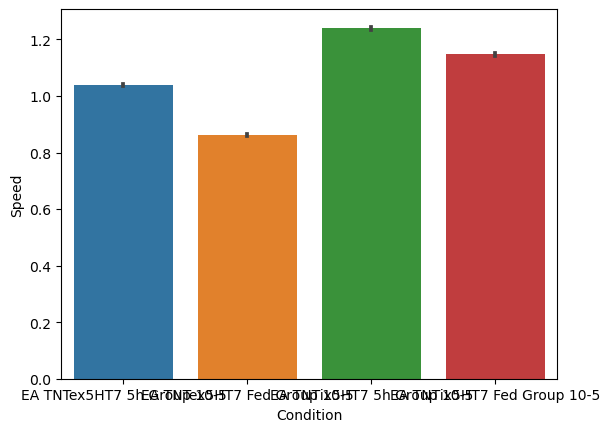

In [22]:
temp_df = df_TNTx5HT7_EA_105[df_TNTx5HT7_EA_105['Speed'] < 2.0]
temp_df = temp_df[temp_df['Speed'] > 0.5] 
sbs.barplot(temp_df, x = 'Condition', y = 'Speed')

In [15]:
statistics.run_two_way_anova(df_TNTx5HT7_EA_105, plot=False)

(                                sum_sq       df            F        PR(>F)
 C(Genotype)                 867.246771      1.0  9426.552561  0.000000e+00
 C(Starvation)               286.035538      1.0  3109.067827  0.000000e+00
 C(Genotype):C(Starvation)    26.575765      1.0   288.865702  1.247286e-64
 Residual                   5494.540932  59723.0          NaN           NaN,
     Genotype Starvation  Mean_Speed  SEM_Speed
 0  TNTex5HT7         5h    1.038806   0.002140
 1  TNTex5HT7        Fed    0.862387   0.001973
 2  TNTix5HT7         5h    1.239263   0.003150
 3  TNTix5HT7        Fed    1.148269   0.002848)

In [17]:
statistics.run_tukey_posthoc(df_TNTx5HT7_EA_105)

d:\Experiment Work\larva-locater Repo\larva-locater\Structured\statistics.py:94: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  # Convert to DataFrame


(<statsmodels.sandbox.stats.multicomp.TukeyHSDResults at 0x2bbef4c5dd0>,
           group1         group2  meandiff   p-adj   lower   upper  reject
 0   TNTex5HT7_5h  TNTex5HT7_Fed   -0.4280  0.0023 -0.7385 -0.1175    True
 1   TNTex5HT7_5h   TNTix5HT7_5h    2.4413  0.0000  2.0649  2.8178    True
 2   TNTex5HT7_5h  TNTix5HT7_Fed    1.8319  0.0000  1.4770  2.1869    True
 3  TNTex5HT7_Fed   TNTix5HT7_5h    2.8693  0.0000  2.4968  3.2418    True
 4  TNTex5HT7_Fed  TNTix5HT7_Fed    2.2599  0.0000  1.9092  2.6107    True
 5   TNTix5HT7_5h  TNTix5HT7_Fed   -0.6094  0.0008 -1.0197 -0.1991    True)

In [ ]:
temp_df_1 = [df_TNTx5HT7_EA_105['Frame'] > 400].groupby(['Condition', 'Trial']).mean()

C:\Users\hpnhp\AppData\Local\Temp\ipykernel_13172\3844269964.py:1: FutureWarning: The default value of numeric_only in DataFrameGroupBy.mean is deprecated. In a future version, numeric_only will default to False. Either specify numeric_only or select only columns which should be valid for the function.
  temp_df_1 = df_TNTx5HT7_EA_105[df_TNTx5HT7_EA_105['Frame'] > 400].groupby(['Condition', 'Trial']).mean()


In [48]:
temp_df_1 = temp_df_1.reset_index()

In [49]:
temp_df_1

,Condition,Trial,Y,X,Speed,VY,Frame,Distance,Preference Index
0,EA TNTex5HT7 5h Group 10-5,S_EA105_1_TNTex5HT7_20250630_174026891_conv,12.902566,14.660038,NaN,NaN,497.514182,11.538577,0.149919
1,EA TNTex5HT7 5h Group 10-5,S_EA105_2_TNTex5HT7_20250630_175345356_conv,14.058351,14.581500,NaN,NaN,498.981221,14.102010,0.287167
2,EA TNTex5HT7 5h Group 10-5,S_EA105_3_TNTex5HT7_20250630_180644668_conv,9.022324,13.808909,NaN,NaN,497.677381,8.466724,0.034921
3,EA TNTex5HT7 5h Group 10-5,S_EA105_4_TNTex5HT7_20250630_174437993_flip_conv,14.325745,15.495057,NaN,NaN,494.588881,12.999011,0.556623
4,EA TNTex5HT7 5h Group 10-5,S_EA105_5_TNTex5HT7_conv,6.824191,11.706657,NaN,NaN,493.293796,6.376198,0.372263
5,EA TNTex5HT7 5h Group 10-5,S_EA105_6_TNTex5HT7_20250630_181022903_conv,15.575711,17.395005,NaN,NaN,495.673527,14.535794,0.674462
6,EA TNTex5HT7 Fed Group 10-5,EA105_1_TNTex5HT7_20250630_154521748_conv,15.828985,14.171110,NaN,NaN,499.805639,14.937879,0.091306
7,EA TNTex5HT7 Fed Group 10-5,EA105_2_TNTex5HT7_20250630_161411532_conv,12.537916,11.155131,NaN,NaN,500.000000,11.398305,-0.473702
8,EA TNTex5HT7 Fed Group 10-5,EA105_3_TNTex5HT7_20250630_162812347_conv,14.474891,13.177018,NaN,NaN,496.781597,14.751923,0.279628
9,EA TNTex5HT7 Fed Group 10-5,EA105_4_TNTex5HT7_20250630_154907927_conv,14.331094,18.692323,NaN,NaN,490.631347,14.246214,0.774834


In [50]:
statistics.analyze_preference_index(temp_df_1)

▶️ Test Used: ANOVA
                     sum_sq    df         F    PR(>F)
C(Q("Condition"))  0.752056   3.0  1.996964  0.148632
Residual           2.385132  19.0       NaN       NaN

▶️ Tukey Post-hoc:
                        group1                       group2  meandiff   p-adj  \
0   EA TNTex5HT7 5h Group 10-5  EA TNTex5HT7 Fed Group 10-5   -0.2109  0.7606   
1   EA TNTex5HT7 5h Group 10-5   EA TNTix5HT7 5h Group 10-5    0.2654  0.5755   
2   EA TNTex5HT7 5h Group 10-5  EA TNTix5HT7 Fed Group 10-5    0.1988  0.7667   
3  EA TNTex5HT7 Fed Group 10-5   EA TNTix5HT7 5h Group 10-5    0.4763  0.1536   
4  EA TNTex5HT7 Fed Group 10-5  EA TNTix5HT7 Fed Group 10-5    0.4097  0.2572   
5   EA TNTix5HT7 5h Group 10-5  EA TNTix5HT7 Fed Group 10-5   -0.0666  0.9877   

    lower   upper  reject  
0 -0.8142  0.3923   False  
1 -0.3098  0.8406   False  
2 -0.3764  0.7740   False  
3 -0.1269  1.0796   False  
4 -0.1935  1.0130   False  
5 -0.6418  0.5086   False  


{'test': 'ANOVA',
 'p': 0.14863229838922992,
 'normality': {'EA TNTex5HT7 5h Group 10-5': 0.9166412353515625,
  'EA TNTex5HT7 Fed Group 10-5': 0.9356922507286072,
  'EA TNTix5HT7 5h Group 10-5': 0.4889522194862366,
  'EA TNTix5HT7 Fed Group 10-5': 0.17182378470897675},
 'anova_table':                      sum_sq    df         F    PR(>F)
 C(Q("Condition"))  0.752056   3.0  1.996964  0.148632
 Residual           2.385132  19.0       NaN       NaN,
 'posthoc':                         group1                       group2  meandiff   p-adj  \
 0   EA TNTex5HT7 5h Group 10-5  EA TNTex5HT7 Fed Group 10-5   -0.2109  0.7606   
 1   EA TNTex5HT7 5h Group 10-5   EA TNTix5HT7 5h Group 10-5    0.2654  0.5755   
 2   EA TNTex5HT7 5h Group 10-5  EA TNTix5HT7 Fed Group 10-5    0.1988  0.7667   
 3  EA TNTex5HT7 Fed Group 10-5   EA TNTix5HT7 5h Group 10-5    0.4763  0.1536   
 4  EA TNTex5HT7 Fed Group 10-5  EA TNTix5HT7 Fed Group 10-5    0.4097  0.2572   
 5   EA TNTix5HT7 5h Group 10-5  EA TNTix5HT7 